# Intraday Put-Call Parity Trades

In this exercise we consider the put-call parity arbitrage. This is known as trading **reversals** and **conversions**.

### Intraday Trading

We have data at various points throughout a trading day. (We collect data every 5 minutes, but there are many intervals in which there is not a trade of both a put and a call. Thus, the data of interest is a smaller subset of data points.)

At every synchronous point, we examine the put-call parity and construct an arbitrage if available.

To avoid trades which would be overwhelmed by transaction costs, we will only put on the arbitrage if put-call parity is violated by at least `0.30` in either direction.

### Data Set

Consider the data in the file

`../data/intraday_options_data_NFLX.xlsx`
* `Info` - find the financing rate and days to expiration.
* `Prices` - collects the price at the end of every 5-min period for which we have data on all three instruments.
* `Options` - extra data which is unnecessary for this exercise.
* `Underlying` - extra data which is unnecessary for this exercise.

Note that
* the interest rate is specific to the horizon to expiration, quoted as ACT/360 with simple compounding.
* there is no dividend.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

TICK = 'NFLX'
THRESHOLD = 0.30

# Load data from Excel file
excel_file = "intraday_options_data_NFLX.xlsx"

# Read each sheet
info = pd.read_excel(excel_file, sheet_name='Info', index_col=None)
prices = pd.read_excel(excel_file, sheet_name='Prices', index_col=0, parse_dates=True)

In [2]:
display(info)

,Parameter,Value
0,Ticker,NFLX
1,Date,2025-07-25
2,Strike Price,$1180.0
3,Finance Rate,4.5866%
4,Dividend Yield,0.0000%
5,Days to Expiry,21
6,Call Ticker,NFLX 08/15/25 C1180 US Equity
7,Put Ticker,NFLX 08/15/25 P1180 US Equity


In [3]:
display(prices.style.format('{:,.2f}'))

,underlying,call,put
2025-07-25 09:30:00,"1,179.58",29.47,27.95
2025-07-25 09:55:00,"1,178.05",29.00,28.80
2025-07-25 10:10:00,"1,186.58",34.00,24.47
2025-07-25 10:30:00,"1,177.59",29.07,27.60
2025-07-25 10:45:00,"1,182.92",31.91,25.85
2025-07-25 11:20:00,"1,184.56",32.30,24.95
2025-07-25 11:35:00,"1,181.90",31.20,26.10
2025-07-25 12:30:00,"1,185.55",32.30,24.46
2025-07-25 12:50:00,"1,186.14",32.50,23.75
2025-07-25 12:55:00,"1,185.76",33.55,23.42


### 1.1.

For every time stamp, calculate the violation of put-call parity.
* Plot the violations over time.
* Report the mean absolution violation.
* Report how many times the violation is larger than our threshold, in either direction.

The mean violation is 0.5572937028503345
The number of violations is 8


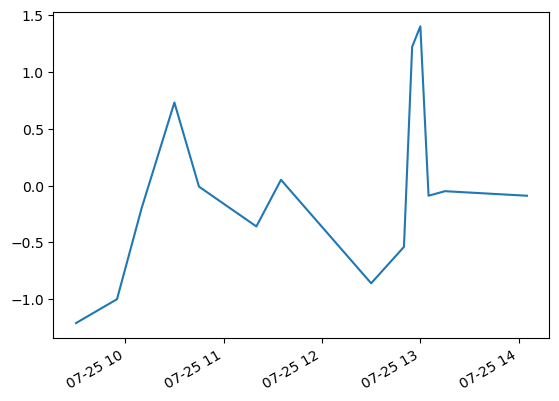

In [21]:
# 1.1 
# Building violations column
r = 0.045866
T = 21/360
PV_K= 1180 / (1 + r * T)
prices['violation'] = (prices['call'] + PV_K) - (prices['put'] + prices['underlying'])
prices.head()

# Plotting violations over time
prices['violation'].plot()

# Mean absolution violation
mean_abs_violation = prices['violation'].abs().mean()
print("The mean violation is", mean_abs_violation)

# Number of times violation is larger than threshold (0.30)
n_violations = (prices['violation'].abs() > 0.3).sum()
print("The number of violations is", n_violations)

### 1.2.

Calculate the total arbitrage profit if we were to trade every violation at a quantity of `1,000` contracts (`100` shares each.) 

* Report the total PnL for the day.
* Plot the transaction PnL at each trade
* Plot the cumulative PnL over the day

Note that 
* we are assuming that if the violation appears in consecutive time stamps (even just 5 min apart) we can trade it both times.
* we only trade violations beyond the threshold described above.

Hint: You don't need to construct the full trade at each timestamp to answer this question.

Total PnL for the day: 731737.0613301591


<Axes: >

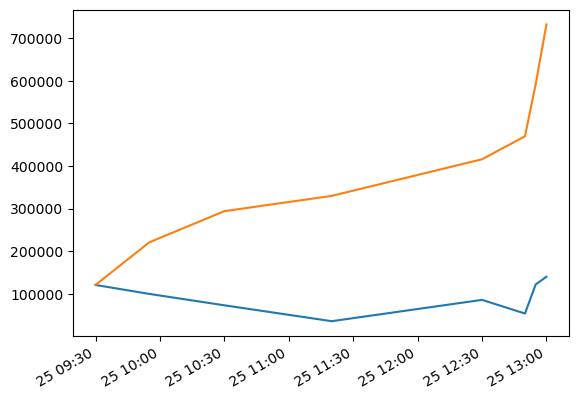

In [41]:
# 1.2
# PnL per trade will = |violation| x (contracts x shares per contract) = |violation| * 100,000
trades = prices[prices['violation'].abs() > 0.3].copy()
trades['pnl'] = trades['violation'].abs() * 100000

total_pnl= trades['pnl'].sum()
print("Total PnL for the day:", total_pnl)

trades['pnl'].plot()
trades['pnl'].cumsum().plot()


### 1.3.

Construct a plot of the cumulative position we hold in calls, puts, shares, and cash throughout the day.

In a table, report the max and min of number
* shares
* call contracts
* put contracts

<Axes: >

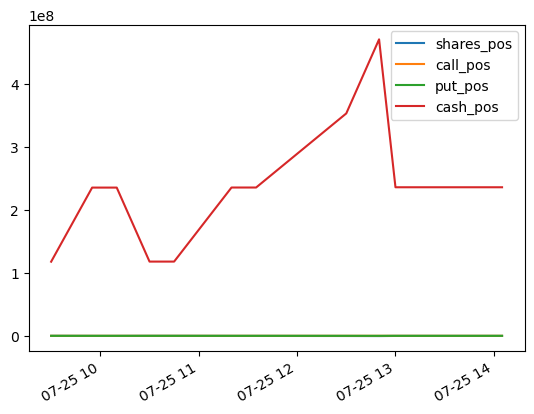

In [46]:
# 1.3 
s = np.sign(trades['violation'])

trades['shares_trade']= 100000 * s
trades['call_trade'] = -1000 * s
trades['put_trade'] = 1000* s
trades['cash_trade'] = 100000 * s * (trades['call'] - trades['put'] - trades['underlying'])

trades['shares_pos'] = trades['shares_trade'].cumsum()
trades['call_pos'] = trades['call_trade'].cumsum()
trades['put_pos'] = trades['put_trade'].cumsum()
trades['cash_pos'] = trades['cash_trade'].cumsum()
positions = trades[['shares_pos','call_pos','put_pos','cash_pos']].reindex(prices.index).ffill().fillna(0)
positions[['shares_pos','call_pos','put_pos']].agg(['max','min'])

positions[['shares_pos', 'call_pos', 'put_pos', 'cash_pos']].plot()



### 1.4.

What is a reason this trade may not generate as much PnL as it appears?

In [ ]:
# One reason is that the violations are computed off single price points rather than 
# a more realistic constantly updating bid-ask spread.  So we would expect times where
# having to sell at the bid and buy at the ask for shares, puts, and calls, would tank some of the 
# profits from the 0.3 violation.  